In [9]:
# Célula 1: Importação das Bibliotecas
import pandas as pd
from scipy.io import arff
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import joblib

print("Ferramentas carregadas com sucesso!")

Ferramentas carregadas com sucesso!


In [10]:
# Célula 2: Carregamento Inteligente do Dataset
import pandas as pd

def consertar_arff_nsl_kdd(caminho_arquivo):
    # Abre o arquivo e lê linha por linha
    with open(caminho_arquivo, 'r') as f:
        linhas = f.readlines()

    colunas = []
    inicio_dados = 0

    # Caça os nomes das colunas e descobre onde a tabela começa
    for i, linha in enumerate(linhas):
        linha = linha.strip()
        if linha.lower().startswith('@attribute'):
            # Pega o nome da coluna e remove qualquer aspas que possa atrapalhar
            nome_coluna = linha.split()[1].replace("'", "")
            colunas.append(nome_coluna)
        elif linha.lower().startswith('@data'):
            inicio_dados = i + 1 # A tabela começa na linha seguinte
            break

    # O Pandas lê os dados ignorando o cabeçalho quebrado
    df = pd.read_csv(caminho_arquivo, skiprows=inicio_dados, header=None, names=colunas)
    return df

print("Lendo os arquivos e corrigindo o erro do Kaggle...")
df_treino = consertar_arff_nsl_kdd('KDDTrain+.arff')
df_teste = consertar_arff_nsl_kdd('KDDTest+.arff')

print(f"O dataset de TREINO tem {df_treino.shape[0]} pacotes.")
print(f"O dataset de TESTE tem {df_teste.shape[0]} pacotes.")
df_treino.head() # Mostra as primeiras linhas para confirmar

Lendo os arquivos e corrigindo o erro do Kaggle...
O dataset de TREINO tem 125973 pacotes.
O dataset de TESTE tem 22544 pacotes.


,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,class
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,25,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal
1,0,udp,other,SF,146,0,0,0,0,0,...,1,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal
2,0,tcp,private,S0,0,0,0,0,0,0,...,26,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,anomaly
3,0,tcp,http,SF,232,8153,0,0,0,0,...,255,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal
4,0,tcp,http,SF,199,420,0,0,0,0,...,255,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal


In [11]:
# Célula 3: Separação de X e y
# X = Tudo menos a classe / y = Apenas a classe
X_treino = df_treino.drop('class', axis=1)
y_treino = df_treino['class']

X_teste = df_teste.drop('class', axis=1)
y_teste = df_teste['class']

print("Separação concluída!")

Separação concluída!


In [12]:
# Célula 4: One-Hot Encoding
print("Convertendo palavras em números lógicos...")
X_treino_convertido = pd.get_dummies(X_treino)
X_teste_convertido = pd.get_dummies(X_teste)

# O alinhamento garante que o arquivo de teste não tenha nenhuma coluna diferente do de treino
X_treino_convertido, X_teste_convertido = X_treino_convertido.align(X_teste_convertido, join='left', axis=1, fill_value=0)

print(f"Pronto! A tabela que tinha 41 colunas originais agora tem {X_treino_convertido.shape[1]} colunas numéricas.")

Convertendo palavras em números lógicos...
Pronto! A tabela que tinha 41 colunas originais agora tem 122 colunas numéricas.


In [13]:
# Célula 5: Treinando a Random Forest
print("Iniciando o aprendizado da IA (Isso pode levar de 1 a 2 minutos)...")

# n_estimators=100 (Cria 100 árvores)
# n_jobs=-1 (Usa todos os núcleos do processador do Google para ser mais rápido)
modelo = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)

# O '.fit' é o comando exato onde a Inteligência Artificial aprende
modelo.fit(X_treino_convertido, y_treino)

print("✅ A Inteligência Artificial concluiu o treinamento!")

Iniciando o aprendizado da IA (Isso pode levar de 1 a 2 minutos)...
✅ A Inteligência Artificial concluiu o treinamento!


Aplicando a prova para a IA...
A PRECISÃO DA SUA IA FOI DE: 76.73%


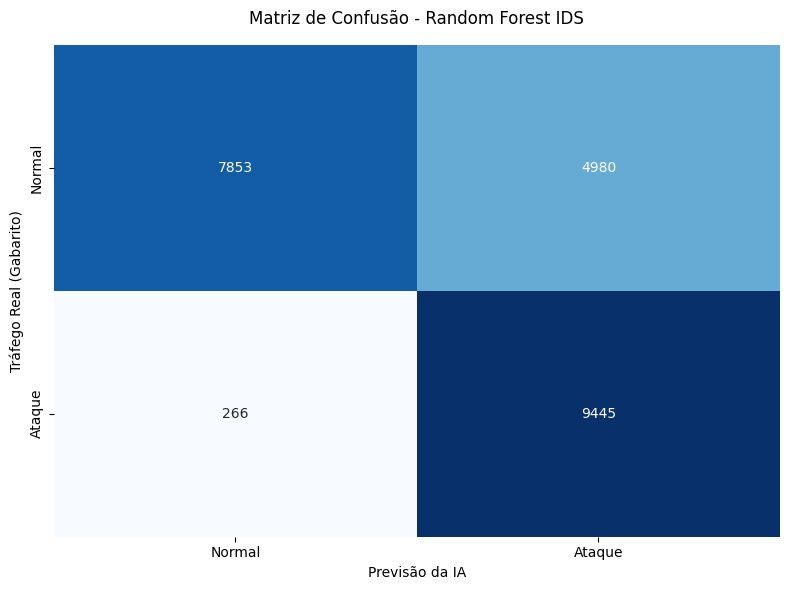

In [14]:
# Célula 6: Testando a Precisão do Modelo
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("Aplicando a prova para a IA...")
previsoes = modelo.predict(X_teste_convertido)

# Calcula as notas dos acertos
precisao = accuracy_score(y_teste, previsoes)

print("=========================================")
print(f"A PRECISÃO DA SUA IA FOI DE: {precisao * 100:.2f}%")
print("=========================================")

#MATRIZ DE CONFUSÃO:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Gera os números da matriz
matriz = confusion_matrix(y_teste, previsoes)

# Configura o visual do gráfico (Mapa de Calor)
plt.figure(figsize=(8, 6))
sns.heatmap(matriz, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Normal', 'Ataque'],
            yticklabels=['Normal', 'Ataque'])

plt.title('Matriz de Confusão - Random Forest IDS', pad=15)
plt.xlabel('Previsão da IA')
plt.ylabel('Tráfego Real (Gabarito)')
plt.tight_layout()

# Mostra o gráfico na tela
plt.show()

In [15]:
# Célula 7: Exportação
joblib.dump(modelo, 'modelo_ids_treinado.pkl')
joblib.dump(X_treino_convertido.columns, 'colunas_treino.pkl')

print("✅ Arquivos exportados com sucesso!")

✅ Arquivos exportados com sucesso!
